<a href="https://colab.research.google.com/github/florcisco/Churn-Prediction/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto: Churn Prediction
Autor: Francisco Lombroni

En este analisis, buscaremos predecir la posibilidad de churn, es decir, de cambio, en este caso, usando un data set de clientes de telecomunicaciones.

## Carga del dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving churn_prediction.csv to churn_prediction.csv


## Importación de librerías

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('churn_prediction.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análisis Exploratorio de Datos (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Como podemos observar, nuestro dataset contiene diversa información de cada cliente, desde distintos servicios contratados, distinta modalidad de contratación, la edad y el tiempo que lleva en la empresa. Además, encontramos en una de las columnas justamente el "Churn", es decir, si el cliente siguió o no en la empresa.

A continuación, veremos la distribución de este "Churn".

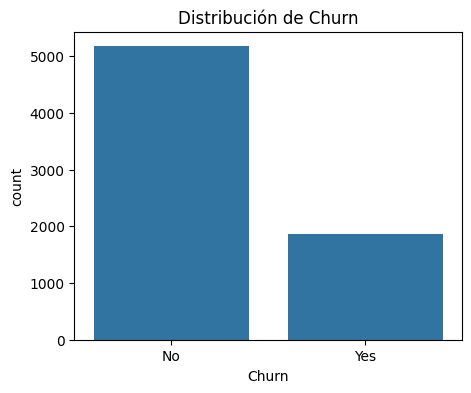

,proportion
Churn,
No,0.73463
Yes,0.26537


In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title("Distribución de Churn")
plt.show()

df['Churn'].value_counts(normalize=True)

Como observamos, la mayoría de los clientes no hizo churn, es decir, siguió con la compañia. Situación típica, por lo que podemos usar este dataset para entrenar nuestros modelos.

También observamos que la columna TotalCharges, que debería ser numérica, está guardada como objeto, por lo que la convertiremos a numero y veremos si tenemos valores vacíos.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna(subset=['TotalCharges'])
df = df.drop(columns=['customerID'])

Como tenemos algunos valores vacios en TotalCharges, que no son muchos, los descartaremos directamente.

Continuaremos viendo la relación de nuestra variable objetivo, "Churn", con las demás, separándo las variables categóricas de las numéricas.

### Variables Numericas

En primer medida, veremos la distribución de churn respecto de las variables numéricas. En este caso, tenemos cuatro variables, que son los gastos mensuales, el total de la factura, el tiempo de permanencia en la empresa y si son personas mayores de 65 o no (esto es lo que nos dice la columna SeniorCitizen, diciendo solamente "sí", 1, o "no", 0).

In [ ]:
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].mean()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
Churn,,,,
No,37.650010,61.307408,2555.344141,0.128995
Yes,17.979133,74.441332,1531.796094,0.254682


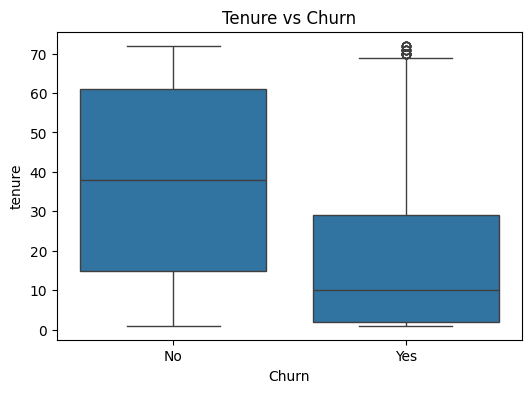

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

Como es de imaginar, en el gráfico de caja se observa que mientras más tiempo lleva en la compañia, menos frecuente es que se vayan, y viceversa. Lo mismo observaremos en el caso de los cargos mensuales, a mayores cargos, son más los clientes que cambian la compañía,a menor valor de la factura, es más frecuente que se queden.

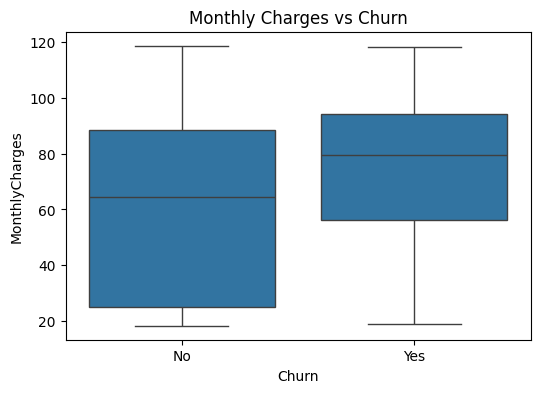

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

### Variables Categoricas

In [ ]:
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

Como observamos, encontramos muchas más variables categóricas, por lo que haremos un mapa de calor para visualizar de mejor manera la relación que hay entre cada una y la posibilidad de churn. Para esto, separaremos el porcentaje de clientes que sí cambiaron de empresa de los que no, en cada variable.

In [ ]:
heatmap_data = []

categorical_features_for_heatmap = [c for c in categorical_cols if c != 'Churn']

for col in categorical_features_for_heatmap:
    counts = df.groupby([col, 'Churn']).size().reset_index(name='count')

    counts['percent'] = (
        counts['count'] /
        counts.groupby(col)['count'].transform('sum')
    ) * 100

    counts['label'] = col + " | " + counts[col].astype(str)

    heatmap_data.append(
        counts.pivot(index='label', columns='Churn', values='percent')
    )

heatmap_df = pd.concat(heatmap_data)

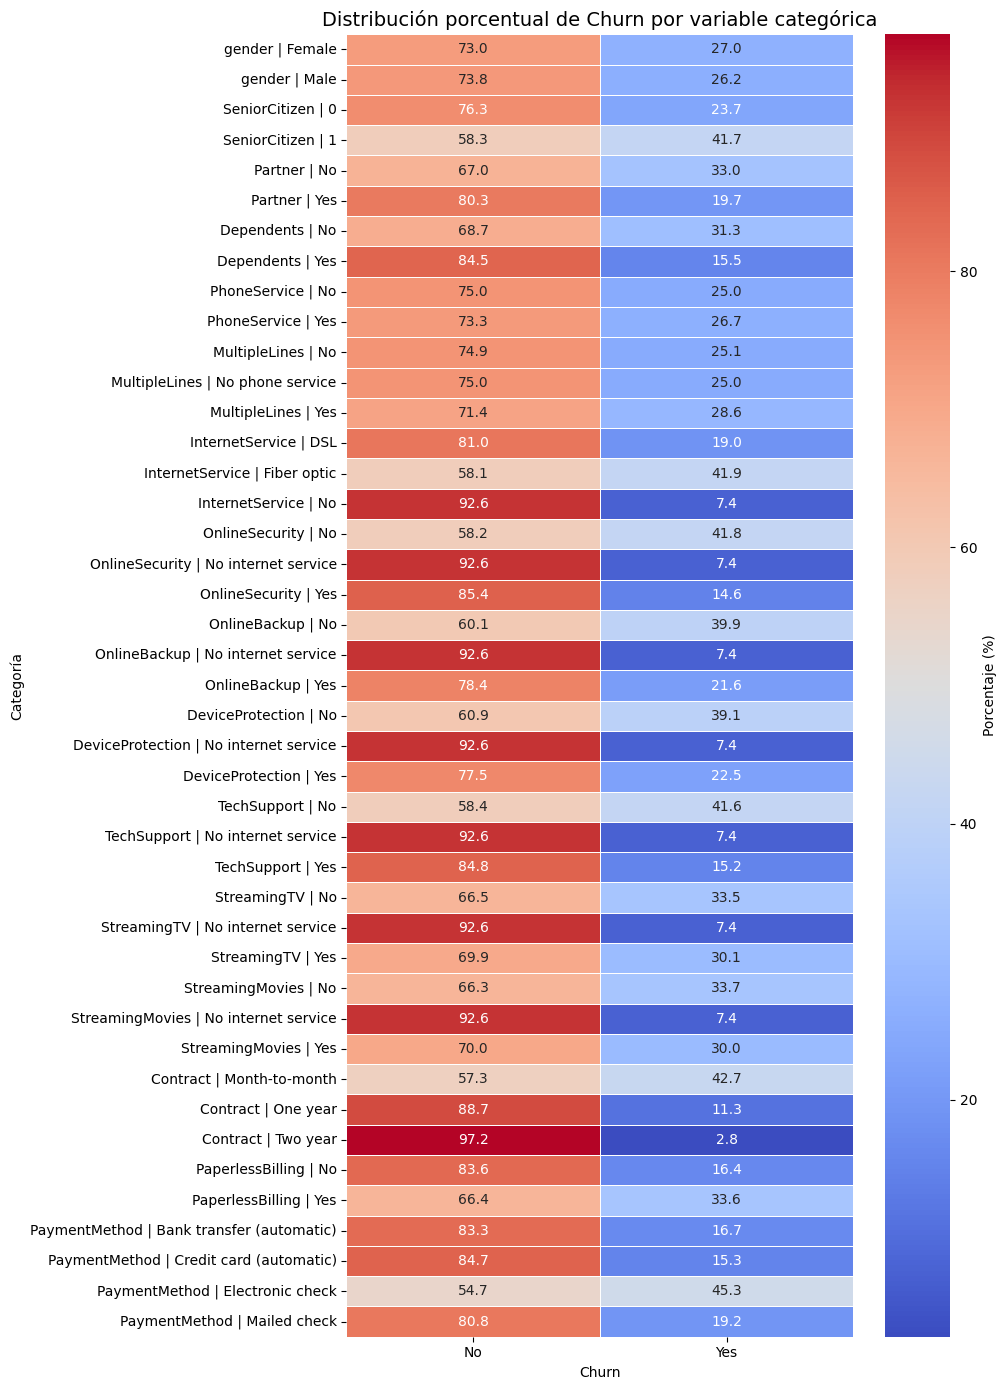

In [ ]:
plt.figure(figsize=(10, 14))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={'label': 'Porcentaje (%)'}
)

plt.title("Distribución porcentual de Churn por variable categórica", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Para observar los porcentajes obtenidos, podemos tener en cuenta que partimos de la base que teniamos una distribución de 73% de No y 27% Si. Cualquier porcentaje mayor al 27, indica una influencia importante en que sí se cambia. Estas serían las variables categóricas que más influencia pueden tener. Se destacan el método de pago, cuando es electrónico, el contrato mes a mes, el no uso del servicio técnico, el caso de gente mayor a 65 y el uso de muchos de los servicios extras.

## Creación de Modelo

Una vez analizado el dataset, pasamos a la creación del modelo. Para esto, haremos one hot encoding para clasificar las variables categóricas, separando nuestra variable objetivo, "Churn", como Y, y el resto del dataset en X. También, transformaremos los valores de No en 0 y Si en 1.

Luego, estandarizaremos las variables numericas, escalandolas.

In [ ]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df_encoded = pd.get_dummies(df, drop_first=True)
X_encoded = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [ ]:
num_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

scaler = StandardScaler()

Continuamos con la selección de variables para nuestro modelo. Para esto, plantearemos primero el listado de correlación, para ver cuanto influye cada una a nuestra variable objetivo, Churn. Cuanto mayor sea el valor de correlación, mayor será la influencia de dicha variable.

In [ ]:
X_corr = X_encoded.astype(float)
correlation = pd.DataFrame({
    'feature': X_corr.columns,
    'correlation': X_corr.corrwith(y)
}).sort_values(by='correlation', key=abs, ascending=False)

correlation.head(20)

,feature,correlation
tenure,tenure,-0.354049
InternetService_Fiber optic,InternetService_Fiber optic,0.307463
Contract_Two year,Contract_Two year,-0.301552
PaymentMethod_Electronic check,PaymentMethod_Electronic check,0.301455
InternetService_No,InternetService_No,-0.227578
OnlineSecurity_No internet service,OnlineSecurity_No internet service,-0.227578
DeviceProtection_No internet service,DeviceProtection_No internet service,-0.227578
TechSupport_No internet service,TechSupport_No internet service,-0.227578
StreamingMovies_No internet service,StreamingMovies_No internet service,-0.227578
StreamingTV_No internet service,StreamingTV_No internet service,-0.227578


Para complementar el listado anterior, plantearemos ahora un Random Forest, para ver la importancia de cada una de las variables.

In [ ]:
rf = RandomForestClassifier(random_state=1)
rf.fit(X_encoded, y)

importances = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importances.head(10)

,feature,importance
3,TotalCharges,0.192823
1,tenure,0.179502
2,MonthlyCharges,0.170417
10,InternetService_Fiber optic,0.042891
28,PaymentMethod_Electronic check,0.035671
25,Contract_Two year,0.029575
4,gender_Male,0.027655
26,PaperlessBilling_Yes,0.025712
13,OnlineSecurity_Yes,0.024091
5,Partner_Yes,0.022802


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

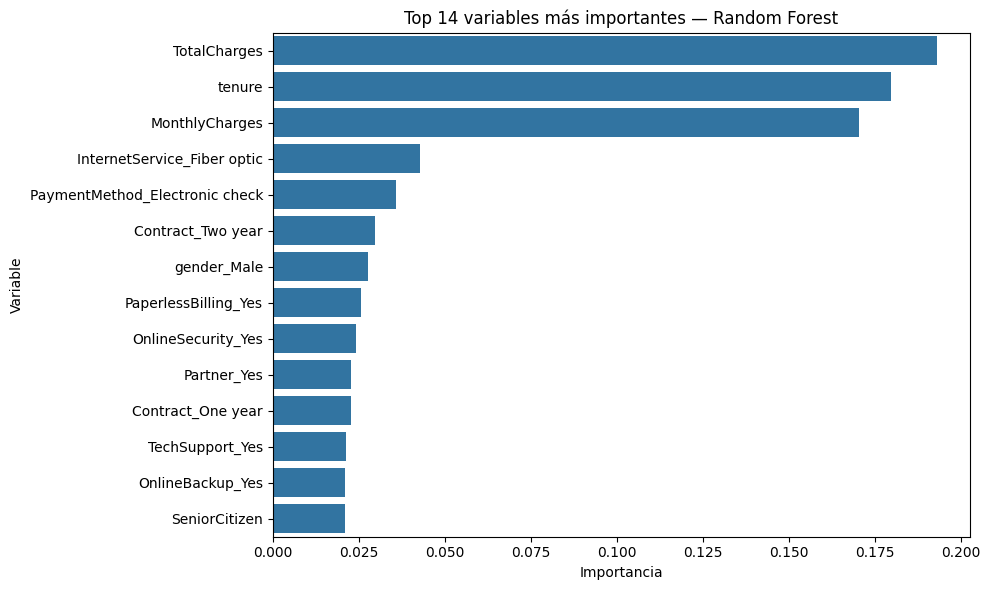

In [ ]:
top_n = 14
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 14 variables más importantes — Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

Finalmente, podemos observar que entre las variables que encontramos con mayor correlación y las que obtuvimos del random forest con mayor importancia hay considerable diferencia. En este punto, vamos a observar ambos listados de las variables con mas correlación e importancia.

In [ ]:
# Variables más correlacionadas con 'Churn'
top_14_corr = correlation.head(14)
top_14_corr_variables = top_14_corr.index

# Variables más importantes en Random Forest
top_rf_features = top_features.head(14)['Feature']

comparison_df = pd.DataFrame({
    'Correlated with Churn': top_14_corr_variables,
    'Random Forest Importance': top_rf_features
})

comparison_df

,Correlated with Churn,Random Forest Importance
3,tenure,TotalCharges
1,InternetService_Fiber optic,tenure
2,Contract_Two year,MonthlyCharges
10,PaymentMethod_Electronic check,InternetService_Fiber optic
28,InternetService_No,PaymentMethod_Electronic check
25,OnlineSecurity_No internet service,Contract_Two year
4,DeviceProtection_No internet service,gender_Male
26,TechSupport_No internet service,PaperlessBilling_Yes
13,StreamingMovies_No internet service,OnlineSecurity_Yes
5,StreamingTV_No internet service,Partner_Yes


Si observamos ambos listados, vemos que excepto "permanencia" ("tenure"), que se encuentra en el top de ambos listados, en lo demás difieren bastante. Cabe destacar que, si bien ambos listados son importantes para ver la influencia en "Churn", ambos ven distintos puntos de vista.

Por un lado, la correlación ve relaciones lineales y bivariadas solamente, sin influencias cruzadas. Por el otro, el random forest mide la importancia de una variable al tomar decisiones. Analiza cruzamientos entre variables, cómo cada una reduce el árbol de posibilidades, los errores, observa relaciones no lineales.

Por todo esto, veremos la intersección entre ambas listas.

In [ ]:
features_corr = top_14_corr.index.tolist()
features_rf = top_features['Feature'].head(14).tolist()
features_combined = list(set(features_corr + features_rf))

corr_set = set(top_14_corr.index)
rf_set = set(top_features.head(14)['Feature'])

intersection = corr_set.intersection(rf_set)
intersection

{'Contract_Two year',
 'InternetService_Fiber optic',
 'MonthlyCharges',
 'PaperlessBilling_Yes',
 'PaymentMethod_Electronic check',
 'TotalCharges',
 'tenure'}

Estas son las variables mejor posicionadas en ambos analisis. Finalmente, para continuar, transformamos las columnas que digan Si en 1, No en 0, y aplicamos one-hot encoding.

Terminado el one hot encoding, ahora podemos pasar al modelado, separando el dataset en variable objetivo ('Churn') y variables predictoras (las demás que no son 'Churn'). Según esto, construiremos nuestro modelo.

Para esto, también separaremos cada una de estas variables en dos, uno para entrenamiento del modelo y otro para su evaluación. Dado que tenemos una gran diferencia entre los clientes que se quedaron en la empresa y los que no, para que estos nuevos grupos sean representativos lo haremos de manera estratificada. Así, ya sea en el grupo de entrenamiento o de testeo, mantendremos la proporción de churn vista originalmente.

In [ ]:
X = X_encoded
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

### Logistic Regression

Para iniciar, empezaremos con un modelo de regresión lógica. Como este modelo se basa en los valores de cada variables, para que ninguna tenga mayor peso que la otra simplemente por sus valores especificos, usaremos el escalado de Python para estandarizar estos valores.

Además, como estamos haciendo un analisis de perdida de clientes, cabe destacar que, en este caso, es más importante perder un cliente que tal vez "molestar" a un cliente que ya tenemos. Por esto, para este modelo, priorizaremos la sensibilidad en detectar posibles casos de perdida, por lo que observaremos principalmente recall y AUC a la hora de evaluar modelos. Siguiendo esta logica para empezar, usaremos un peso de clases balanceado y dejaremos el valor límite por defecto, para analizarlo posteriormente.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_reg = LogisticRegression(max_iter=10000, random_state=1, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=1)

In [ ]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7341862117981521
Precision: 0.5
Recall: 0.8021390374331551
F1: 0.6160164271047228
ROC AUC: 0.8302359049753845


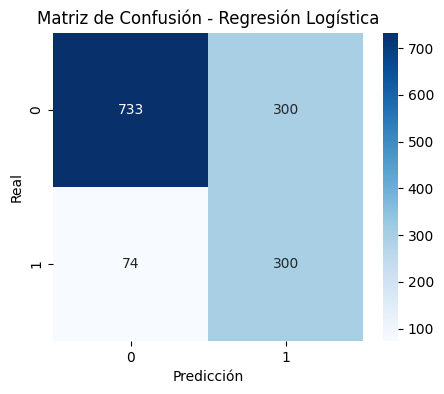

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Regresión Logística")
plt.show()

In [ ]:
TN, FP, FN, TP = cm_lr.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 374
Falsos Positivos (FP): 300 (80.21%)
Falsos Negativos (FN): 74 (19.79%)


En este primer modelo de regresión, vemos que tenemos una buena precisión, recall y AUC. De estos tres, dado que analizamos "Churn", nos interesan más la precisión y el recall. El recall, en primer punto, es el factor que más nos importa, ya que es el que nos va a permitir retener la mayor cantidad de clientes. En esta parte, tenemos un recall bastante alto, aproximadamente 0.8. La precisión del modelo, que es la capacidad de distinguir entre quienes se irian y quienes no con la menor cantidad de errores, en este caso está un poco baja, veremos si podemos mejorarlo. Sin embargo, es menos importante que el recall ya que es preferible contactar clientes de más antes que perder más clientes de los que se irian.

Para esto, modificaremos el umbral que usa el modelo para distinguir churn y no churn, y veremos si mejora. Usaremos un umbral de 0.6

In [ ]:
threshold_lr = 0.6
y_pred_lr_thresh = (y_prob >= threshold_lr).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_thresh))
print("Precision:", precision_score(y_test, y_pred_lr_thresh))
print("Recall:", recall_score(y_test, y_pred_lr_thresh))
print("F1:", f1_score(y_test, y_pred_lr_thresh))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7640369580668088
Precision: 0.5443037974683544
Recall: 0.6898395721925134
F1: 0.6084905660377359
ROC AUC: 0.8302359049753845


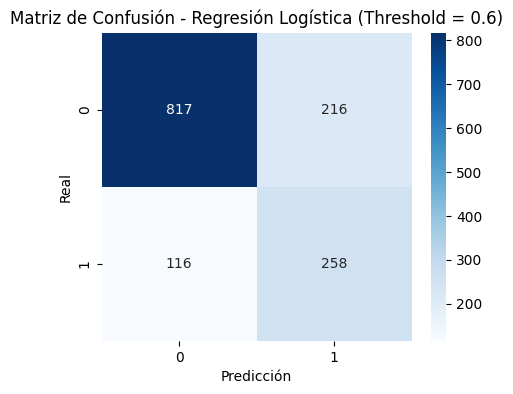

In [ ]:
cm_lr_thresh = confusion_matrix(y_test, y_pred_lr_thresh)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_thresh, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Regresión Logística (Threshold = {threshold_lr})")
plt.show()

In [ ]:
TN, FP, FN, TP = cm_lr_thresh.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 332
Falsos Positivos (FP): 216 (65.06%)
Falsos Negativos (FN): 116 (34.94%)


Al ajustar el umbral para que la precisión mejore, vemos que efectivamente mejoró, disminuyendo la cantidad de errores totales (pasó de 374 a 332), pero aumentaron en buena proporcion los falsos negativos. Estos errores ocurren cuando el modelo predijo que no cambiarían, y sí lo hicieron, que es el error que más nos afecta, ya que perdimos clientes y el modelo no lo predijo. En este punto, depende de los costos que nos convendría usar.

Para ver la evolución según estos indicadores, haremos un grafico de precisión y recall según el threshold.

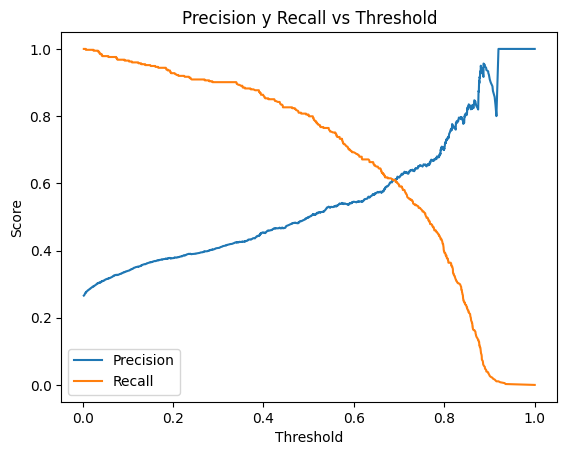

In [ ]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

thresholds = np.append(thresholds, 1)

plt.figure()
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision y Recall vs Threshold")
plt.legend()

plt.show()

Observamos que como debería ser, baja el recall a medida que aumenta la precisión. Podemos observar un cruzamiento un poco más arriba de 0.6 de threshold, que sería un buen punto de equilibrio, pero en nuestro caso nos interesa más el recall.

Por esto, buscaremos un valor de umbral más bajo, dando mayor importancia al recall. Para elegir, haremos una tabla según el threshold, entre 0.1 y 0.4, con la precisión, el recall y el f1 para cada valor. No graficaremos AUC, que es igual de importante, pero que por la forma en que se calcula no cambia para todo el modelo, y se mantiene en 0.83.

In [ ]:
thresholds = np.linspace(0.1, 0.5, 18)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print(f"Threshold: {t:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

Threshold: 0.10 | Precision: 0.34 | Recall: 0.97 | F1: 0.50
Threshold: 0.12 | Precision: 0.35 | Recall: 0.96 | F1: 0.51
Threshold: 0.15 | Precision: 0.36 | Recall: 0.95 | F1: 0.53
Threshold: 0.17 | Precision: 0.37 | Recall: 0.94 | F1: 0.53
Threshold: 0.19 | Precision: 0.38 | Recall: 0.93 | F1: 0.54
Threshold: 0.22 | Precision: 0.38 | Recall: 0.92 | F1: 0.54
Threshold: 0.24 | Precision: 0.39 | Recall: 0.91 | F1: 0.55
Threshold: 0.26 | Precision: 0.39 | Recall: 0.91 | F1: 0.55
Threshold: 0.29 | Precision: 0.40 | Recall: 0.90 | F1: 0.56
Threshold: 0.31 | Precision: 0.41 | Recall: 0.90 | F1: 0.57
Threshold: 0.34 | Precision: 0.42 | Recall: 0.90 | F1: 0.58
Threshold: 0.36 | Precision: 0.43 | Recall: 0.88 | F1: 0.58
Threshold: 0.38 | Precision: 0.44 | Recall: 0.88 | F1: 0.58
Threshold: 0.41 | Precision: 0.46 | Recall: 0.85 | F1: 0.59
Threshold: 0.43 | Precision: 0.47 | Recall: 0.84 | F1: 0.60
Threshold: 0.45 | Precision: 0.47 | Recall: 0.83 | F1: 0.60
Threshold: 0.48 | Precision: 0.48 | Reca

Con estos valores, podríamos elegir cualquier umbral que tenga un recall alto, ya que tenemos un F1 score bastante igual y las diferencias en precisión no son considerables tampoco. Según la situación y el costo económico de retener clientes, se podría mover algo más arriba o más abajo el umbral. Para un análisis general, podremos usar un valor cercano a 0.3.

### RANDOM FOREST

Terminado el análisis de regresión lógica, probaremos ahora un random forest. Al igual que antes, usaremos un modelo con clases balanceadas.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

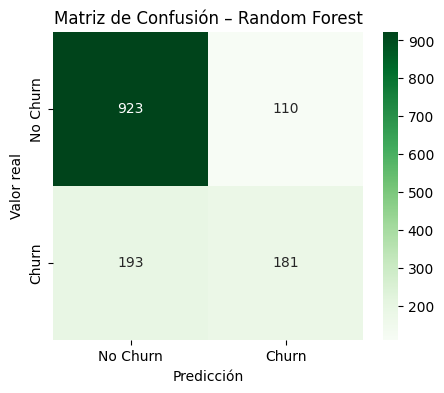

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión – Random Forest')
plt.show()

In [ ]:
TN, FP, FN, TP = cm_rf.ravel()
total_errores = FP + FN
porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 303
Falsos Positivos (FP): 110 (36.30%)
Falsos Negativos (FN): 193 (63.70%)


Veremos que para iniciar, tenemos más o menos la misma cantidad de errores que al principio teniamos en la regresión lógica, pero distinta proporción entre falsos positivos y negativos. Dado que los falsos negativos son los que más nos afectan al modelo, veremos de mejorar este punto.

Para mejorar el bosque de decisión, especificaremos algunas features del modelo. Usaremos un bosque un poco más grande, limitando las caracteristicas de cada arbol.

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=1
)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=1)

In [ ]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

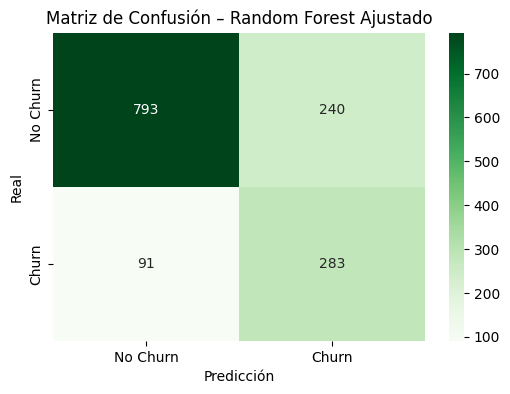

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión – Random Forest Ajustado')
plt.show()

Vemos una clara mejoría en la predicción de falsos negativos, pero un aumento considerable también en falsos positivos. Es lógico esta relación, aunque destacamos que no aumentó el total de errores finales, y se mantiene en una cantidad comparable con el modelo de regresión lógica.

Al igual que con regresión lógica, veremos como varían la precisión y el recall según algunos valores de umbral, para definir que nos conviene.

In [ ]:
y_prob_rf = rf_tuned.predict_proba(X_test)[:, 1]
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob_rf >= t).astype(int)
    print(f"Threshold {t} → Recall:", recall_score(y_test, y_pred))
    print(f"Threshold {t} → Precision:", precision_score(y_test, y_pred))

Threshold 0.2 → Recall: 0.9197860962566845
Threshold 0.2 → Precision: 0.38137472283813745
Threshold 0.3 → Recall: 0.8743315508021391
Threshold 0.3 → Precision: 0.42084942084942084
Threshold 0.4 → Recall: 0.839572192513369
Threshold 0.4 → Precision: 0.48382126348228044
Threshold 0.5 → Recall: 0.7566844919786097
Threshold 0.5 → Precision: 0.5411089866156787
Threshold 0.6 → Recall: 0.6524064171122995
Threshold 0.6 → Precision: 0.6115288220551378


Al igual que pasaba con los errores, vemos que los valores de precisión y recall según el umbral son bastantes similares a los de regresión lógica, por lo que no podemos destacar ninguno de estos modelos por encima del otro.

Para confirmarlo, veremos el gráfico de probabilidades de cada modelo.

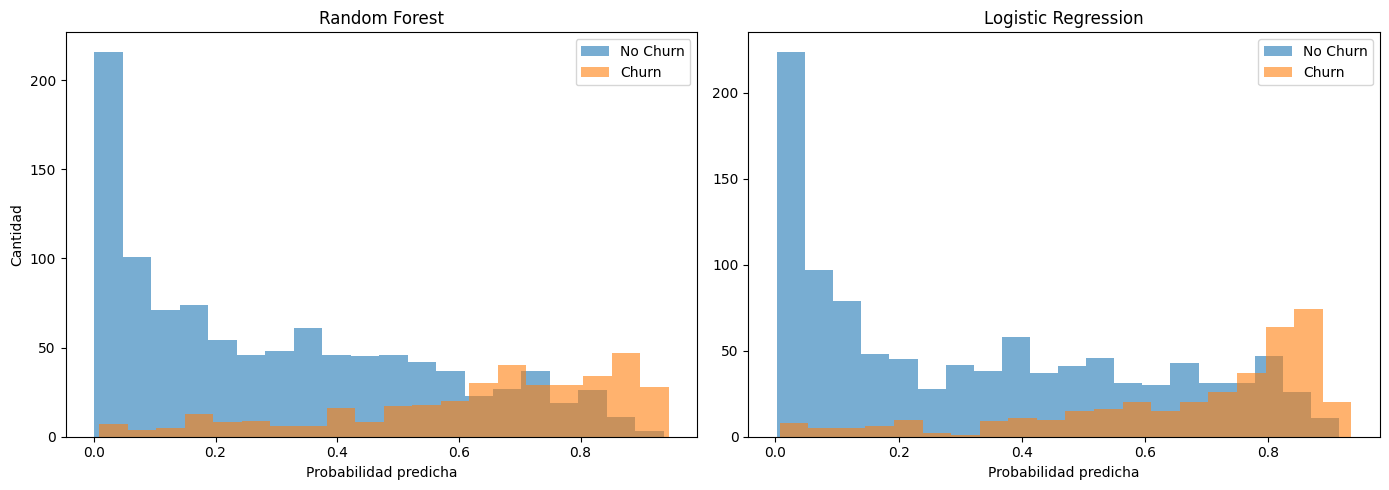

In [ ]:
y_prob_rf = rf_tuned.predict_proba(X_test)[:, 1]
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

rf_churn = y_prob_rf[y_test == 1]
rf_no_churn = y_prob_rf[y_test == 0]

lr_churn = y_prob_lr[y_test == 1]
lr_no_churn = y_prob_lr[y_test == 0]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Random Forest
axes[0].hist(rf_no_churn, bins=20, alpha=0.6, label='No Churn')
axes[0].hist(rf_churn, bins=20, alpha=0.6, label='Churn')
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Cantidad")
axes[0].legend()

# Logistic Regression
axes[1].hist(lr_no_churn, bins=20, alpha=0.6, label='No Churn')
axes[1].hist(lr_churn, bins=20, alpha=0.6, label='Churn')
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].legend()

plt.tight_layout()
plt.show()

Como se observa en el grafico, el comportamiento de ambos modelos es bastante similar, sin prevalencia de uno sobre el otro.

Finalmente, también comparando ambos modelos, planteamos la curva ROC, para ver si alguno destaca realmente en algún valor de umbral.

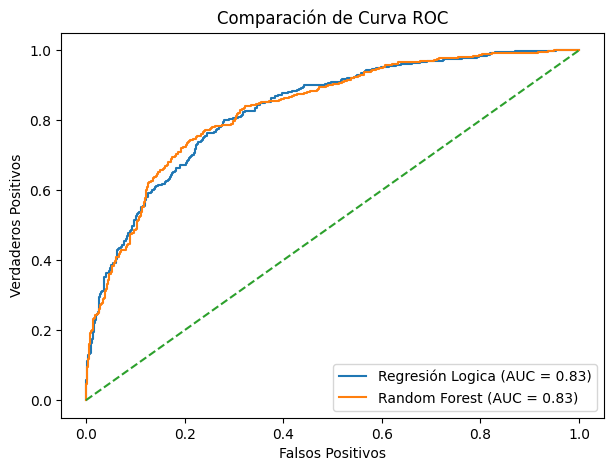

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logica (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.title("Comparación de Curva ROC")

plt.legend()
plt.show()

Como podemos observar, se mantiene el comportamiento similar entre modelos, destacándose uno sobre otro por momentos breves. También, debemos destacar que ambos tienen un buen comportamiento en la predicción de churn, ya que tienen un buen valor de AUC. A su vez, destacamos nuevamente que un valor umbral entre 0.3-0.4 serviría para equilibrar entre detectar clientes con churn y limitar la cantidad de falsos positivos.

## Mejoramiento de Modelo

Ahora, para mejorar la evaluación de los modelos, aprovecharemos que contamos con un dataset de tamaño intermedio y utilizaremos validación cruzada. Con este método, dividiremos el dataset en cinco partes (folds), utilizando cuatro para entrenamiento y una para validación, repitiendo el proceso cinco veces para obtener una evaluación más robusta y estable del rendimiento de los modelos.

Como aspecto importante, utilizaremos una validación cruzada estratificada (StratifiedKFold), de manera que cada fold mantenga aproximadamente la misma proporción de clientes con y sin churn presente en el dataset original.

In [ ]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=10000,
        class_weight='balanced',
        random_state=1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scores_auc = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

scores_recall = cross_val_score(
    pipe_lr,
    X,
    y,
    cv=cv,
    scoring='recall'
)

print("SCORES DE REGRESION LOGICA")
print("AUC por fold:", scores_auc)
print("AUC promedio:", scores_auc.mean())

print("\nRecall por fold:", scores_recall)
print("Recall promedio:", scores_recall.mean())

SCORES DE REGRESION LOGICA
AUC por fold: [0.83746007 0.82862076 0.84722132 0.85335313 0.86033428]
AUC promedio: 0.8453979110289909

Recall por fold: [0.80213904 0.77272727 0.8310992  0.80748663 0.79679144]
Recall promedio: 0.8020487161474387


In [ ]:
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scores_auc_rf = cross_val_score(
    pipe_rf,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

scores_recall_rf = cross_val_score(
    pipe_rf,
    X,
    y,
    cv=cv,
    scoring='recall'
)

print("SCORES DE RANDOM FOREST")
print("AUC por fold:", scores_auc_rf)
print("AUC promedio:", scores_auc_rf.mean())

print("\nRecall por fold:", scores_recall_rf)
print("Recall promedio:", scores_recall_rf.mean())

SCORES DE RANDOM FOREST
AUC por fold: [0.83601705 0.83058534 0.8439045  0.85669667 0.86267644]
AUC promedio: 0.8459759999657516

Recall por fold: [0.7459893  0.71122995 0.74798928 0.77272727 0.77005348]
Recall promedio: 0.749597855227882


Observando el resultado de ambos modelos, vemos que presentan un comportamiento bastante consistente entre los distintos folds, indicando que ambos generalizan de manera estable sobre diferentes particiones del dataset.

Respecto de la comparación entre modelos, observamos que el valor promedio de AUC es prácticamente igual en ambos casos. Sin embargo, la regresión logística presenta un recall promedio superior al de Random Forest, lo que resulta especialmente importante en este problema, ya que nuestro objetivo principal es detectar la mayor cantidad posible de clientes con riesgo de churn.

También, se observa que Random Forest presenta una variabilidad ligeramente mayor entre folds, siendo algunos más cercanos a los valores de Regresión Lógica y otros más lejos.

Continuando con las mejoras, hasta ahora hemos hecho muchas elecciones de parametros manualmente, por lo que haremos un GridSearch probando distintos valores.

En ese sentido, como sabemos, tenemos más parametros para ajustar en Random Forest que en Regresión Lógica, por lo que veremos más variables en el primer modelo, y probablemente más cambio en los resultados obtenidos.

In [ ]:
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 5],
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Mejores parámetros:")
print(grid_rf.best_params_)

print("\nMejor recall promedio:")
print(grid_rf.best_score_)

Mejores parámetros:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Mejor recall promedio:
0.8111353242247423


In [ ]:
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_lr.fit(X, y)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'model__C': 0.01, 'model__solver': 'liblinear'}
0.8031139338504107


Observando los resultados obtenidos mediante GridSearch, vemos que Random Forest logró una mejora considerable en recall, superando incluso a Regresión Lógica. Esto indica que el ajuste de hiperparámetros tuvo un impacto importante en el rendimiento del modelo, especialmente en su capacidad para detectar clientes con churn.

Sin embargo, todavía será necesario analizar otras métricas como precisión, F1-score y AUC, para verificar si esta mejora en recall no genera un exceso de falsos positivos.

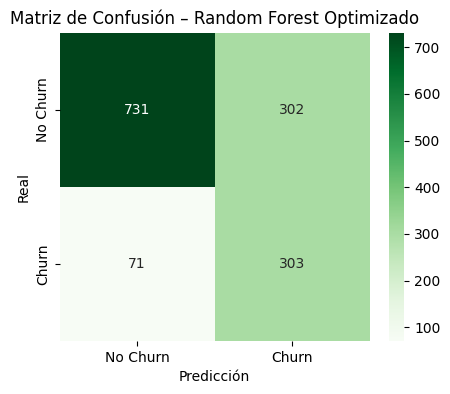

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión – Random Forest Optimizado")
plt.show()

In [ ]:
TN, FP, FN, TP = cm_best_rf.ravel()

total_errores = FP + FN

porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 373
Falsos Positivos (FP): 302 (80.97%)
Falsos Negativos (FN): 71 (19.03%)


In [ ]:
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("F1:", f1_score(y_test, y_pred_best_rf))
print("ROC AUC:", roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:,1]
))

Recall: 0.8101604278074866
Precision: 0.5008264462809917
F1: 0.6189989785495403
ROC AUC: 0.8423314058528455


Viendo la cantidad de errores y los valores de precisión, recall y F1 obtenidos, observamos que el modelo mantiene métricas similares a las trabajadas anteriormente. Sin embargo, el Random Forest optimizado logró una mejora en recall, aumentando su capacidad para detectar clientes con churn.

Como contrapartida, la precisión disminuyó levemente, lo que indica un aumento en la cantidad de falsos positivos. Este comportamiento era esperable, ya que al priorizar la detección de churn, el modelo tiende a clasificar más clientes como posibles casos de abandono.

A pesar de esto, el modelo mantiene un buen equilibrio general, reflejado tanto en el F1-score como en el valor de AUC obtenido.

Con este nuevo Random Forest optimizado, podemos competir directamente con Logistic Regression, como veremos en el cuadro abajo realizado, quedando entonces como el modelo con mejores métricas.

In [ ]:
comparison_models = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'Random Forest Optimizado'
    ],

    'Recall': [
        0.8021,
        0.7567,
        0.8102
    ],

    'Precision': [
        0.5000,
        0.5411,
        0.5008
    ],

    'F1 Score': [
        0.6160,
        0.6260,
        0.6190
    ],

    'ROC AUC': [
        0.8302,
        0.8460,
        0.8423
    ]
})

comparison_models

,Modelo,Recall,Precision,F1 Score,ROC AUC
0,Logistic Regression,0.8021,0.5000,0.616,0.8302
1,Random Forest,0.7567,0.5411,0.626,0.8460
2,Random Forest Optimizado,0.8102,0.5008,0.619,0.8423


## XGBOOST

Para finalizar, no podríamos evitar probar XGBoost.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
print("Recall:", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

Recall: 0.7727272727272727
Precision: 0.5302752293577981
F1: 0.6289445048966268
ROC AUC: 0.8232848098317035


En esta primera versión, con parámetros más generales, vemos que las métricas no se acercan a los valores que estabamos encontrando. Haremos una prueba más específica, más dedicada a mejorar el recall, que es nuestra métrica más importante.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=4,
    random_state=1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Recall:", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

Recall: 0.8155080213903744
Precision: 0.47730829420970267
F1: 0.6021717670286278
ROC AUC: 0.8250707921996574


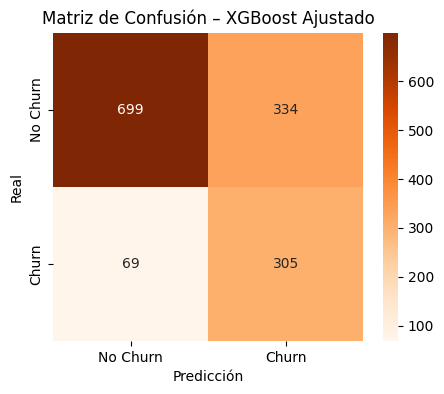

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión – XGBoost Ajustado")
plt.show()

In [ ]:
TN, FP, FN, TP = cm_xgb.ravel()

total_errores = FP + FN

porc_fp = FP / total_errores
porc_fn = FN / total_errores

print(f"Total de errores: {total_errores}")
print(f"Falsos Positivos (FP): {FP} ({porc_fp:.2%})")
print(f"Falsos Negativos (FN): {FN} ({porc_fn:.2%})")

Total de errores: 403
Falsos Positivos (FP): 334 (82.88%)
Falsos Negativos (FN): 69 (17.12%)


En este último caso, vemos una clara mejoría en el recall obtenido, alcanzando el valor más alto entre todos los modelos analizados. Esto indica que XGBoost logró detectar una mayor cantidad de clientes con churn.

Sin embargo, esta mejora ocurrió a costa de una disminución en precisión y un aumento considerable de falsos positivos. Como consecuencia, también fue el modelo con mayor cantidad total de errores.

Esto refleja nuevamente el tradeoff entre recall y precisión: al priorizar la detección de churn, el modelo se vuelve más agresivo al clasificar clientes como posibles casos de abandono.

# Conclusión Final

Para finalizar, empezaremos mostrando una tabla resumen de las métricas de los mejores modelos, para tenerlo bien presente.

In [ ]:
comparison_models = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'Random Forest Optimizado',
        'XGBoost Ajustado'
    ],

    'Recall': [
        0.8021,
        0.7567,
        0.8102,
        0.8155
    ],

    'Precision': [
        0.5000,
        0.5411,
        0.5008,
        0.4773
    ],

    'F1 Score': [
        0.6160,
        0.6260,
        0.6190,
        0.6022
    ],

    'ROC AUC': [
        0.8302,
        0.8460,
        0.8423,
        0.8251
    ],

    'Total Errores': [
        374,
        303,
        373,
        403
    ]
})

comparison_models.style.format({
    'Recall': '{:.3f}',
    'Precision': '{:.3f}',
    'F1 Score': '{:.3f}',
    'ROC AUC': '{:.3f}'
})

,Modelo,Recall,Precision,F1 Score,ROC AUC,Total Errores
0,Logistic Regression,0.802,0.500,0.616,0.830,374
1,Random Forest,0.757,0.541,0.626,0.846,303
2,Random Forest Optimizado,0.810,0.501,0.619,0.842,373
3,XGBoost Ajustado,0.816,0.477,0.602,0.825,403


A lo largo del proyecto analizamos distintos modelos de machine learning con el objetivo de predecir la pérdida de clientes (churn). Para ello, probamos modelos de Logistic Regression, Random Forest y XGBoost, evaluando distintas configuraciones y ajustes de hiperparámetros.

En términos generales, todos los modelos obtuvieron resultados similares, especialmente en métricas globales como ROC AUC y F1-score. Sin embargo, dado el problema analizado, se priorizó principalmente el recall, ya que para la empresa resulta más costoso perder un cliente que realizar contactos adicionales en campañas de retención. En segundo lugar, también se consideró la precisión, buscando limitar la cantidad de falsos positivos generados.

Bajo estas condiciones, Logistic Regression mostró un rendimiento sólido desde el inicio, requiriendo pocos ajustes para alcanzar métricas competitivas. Por su parte, Random Forest logró mejorar sus resultados generales luego del proceso de optimización mediante GridSearch, manteniendo métricas equilibradas y una cantidad de errores comparable. Cabe destacar que, en su versión inicial, fue el modelo con menor cantidad total de errores, aunque sacrificando recall.

Finalmente, XGBoost obtuvo el mayor recall entre todos los modelos evaluados, mostrando una gran capacidad para detectar clientes con riesgo de churn. No obstante, esta mejora estuvo acompañada por una disminución en precisión y un aumento considerable en falsos positivos y errores totales.

En conclusión, no existe un modelo claramente superior en todos los aspectos. La elección final dependerá principalmente de la estrategia de negocio de la empresa y del costo asociado tanto a la pérdida de clientes como a las campañas de retención implementadas.